# Projet ft_linear_regression
Ce projet a pour but de faire comprendre le machine learning ainsi que de m'initier à différents outils comme Jupyter

## Entrainement



In [61]:
import numpy as np

ITERATIONS = 1000
LEARNING_RATE = 0.01

def load_data(file_path):
    data = np.loadtxt(file_path, delimiter=',', skiprows=1)
    mileage = data[:, 0]
    price = data[:, 1]
    return mileage, price


def normalize_data(data):
    mean = np.mean(data)
    std = np.std(data)
    normalized_data = (data - mean) / std
    return normalized_data, mean, std


def compute_cost(mileage, price, theta0, theta1):
    m = len(price)
    predictions = theta0 + theta1 * mileage
    cost = (1 / (2 * m)) * np.sum((predictions - price) ** 2)
    return cost


def gradient_descent(mileage, price, theta0, theta1, learning_rate, iterations):
    m = len(price)
    for _ in range(iterations):
        predictions = theta0 + theta1 * mileage
        tmp_theta0 = theta0 - learning_rate * (1 / m) * np.sum(predictions - price)
        tmp_theta1 = theta1 - learning_rate * (1 / m) * np.sum((predictions - price) * mileage)

        theta0, theta1 = tmp_theta0, tmp_theta1
    return theta0, theta1


def save_file(theta0: float, theta1: float):
    file = open('csv/weight', 'w')
    file.write(str(theta0))
    file.write('\n')
    file.write(str(theta1))

    file.close()

if __name__ == '__main__':
    mileage, price = load_data('csv/data.csv')

    normalized_mileage, mileage_mean, mileage_std = normalize_data(mileage)
    normalized_price, price_mean, price_std = normalize_data(price)

    theta0 = 0.0
    theta1 = 0.0

    theta0, theta1 = gradient_descent(normalized_mileage, normalized_price, theta0, theta1, LEARNING_RATE, ITERATIONS)

    theta1 = theta1 * price_std / mileage_std
    theta0 = price_mean - theta1 * mileage_mean

    save_file(theta0, theta1)

## Prediction

Pour faire la prediction, le sujet nous demande de suivre la formule suivante `estimateP rice(mileage) = θ0 + (θ1 ∗ mileage)`

In [62]:
import pandas as pd

theta0, theta1 = 0.0, 0.0

try:
    with open('csv/weight', 'r') as file:
        theta0, theta1 = map(float, file.read().split())
except FileNotFoundError:
    pass

def predict_price(mileage: int):
    return theta0 + theta1 * mileage

data = pd.read_csv('csv/data.csv')
prices = []

for km in data['km']:
    prices.append(predict_price(km))

pd.DataFrame({"km": data['km'], 'price': prices})

,km,price
0,240000,3351.977038
1,139800,5501.070406
2,150500,5271.576404
3,185530,4520.251646
4,176000,4724.651445
5,114800,6037.271347
6,166800,4921.973391
7,89000,6590.630717
8,144500,5400.264630
9,84000,6697.870905


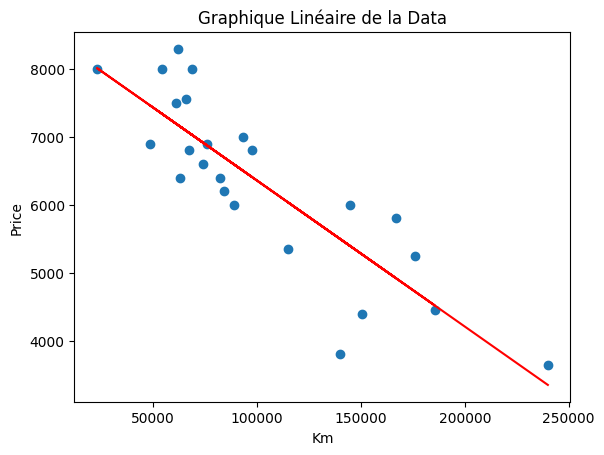

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('csv/data.csv')

plt.plot(data['km'], prices, 'r')
plt.scatter(data['km'], data['price'])

plt.xlabel('Km')
plt.ylabel('Price')
plt.title('Graphique Linéaire de la Data')

plt.show()